## Dependency Installation

In [4]:
!pip install xgboost -q
!pip install lightgbm -q
!pip install catboost -q

## Library Imports & Configuration


In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import random
import zipfile
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.fft import fft
from scipy.signal import find_peaks

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    brier_score_loss
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from IPython.display import display

print("Libraries Loaded Successfully")

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

Libraries Loaded Successfully


# Data Loading

In [6]:
zip_file_path = "/content/archive.zip"
extract_dir = "/content/dataset"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

train_df = pd.read_csv(os.path.join(extract_dir, "exoTrain.csv"))
test_df = pd.read_csv(os.path.join(extract_dir, "exoTest.csv"))

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (5087, 3198)
Test Shape : (570, 3198)


# Target Variable Preparation

In [7]:
X_train = train_df.drop("LABEL", axis=1)
X_test = test_df.drop("LABEL", axis=1)

y_train = train_df["LABEL"].replace({1: 0, 2: 1}).astype(int)
y_test = test_df["LABEL"].replace({1: 0, 2: 1}).astype(int)

print("Train target distribution:")
print(y_train.value_counts())

Train target distribution:
LABEL
0    5050
1      37
Name: count, dtype: int64


# Data Quality Assessment

In [8]:
print("\nMissing Values:", X_train.isnull().sum().sum())
print("Duplicates:", train_df.duplicated().sum())
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)


Missing Values: 0
Duplicates: 0
Train Shape: (5087, 3197)
Test Shape : (570, 3197)


# Exploratory Data Analysis (EDA)

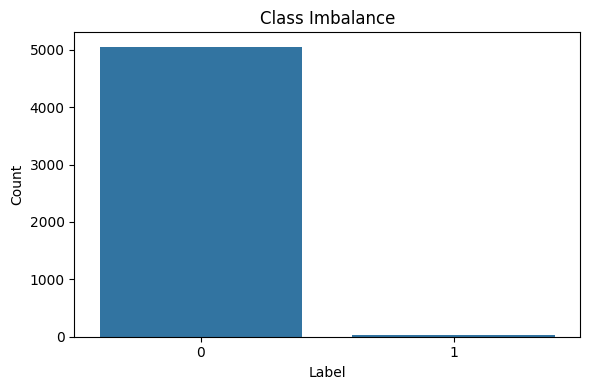

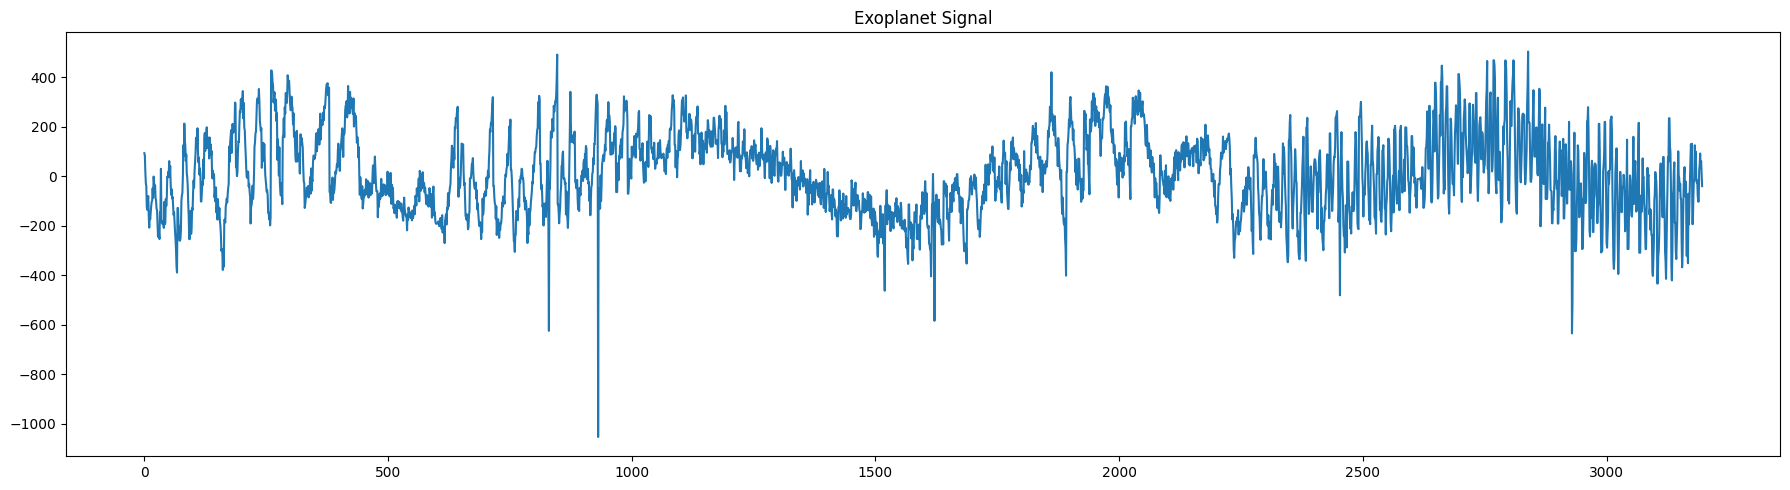

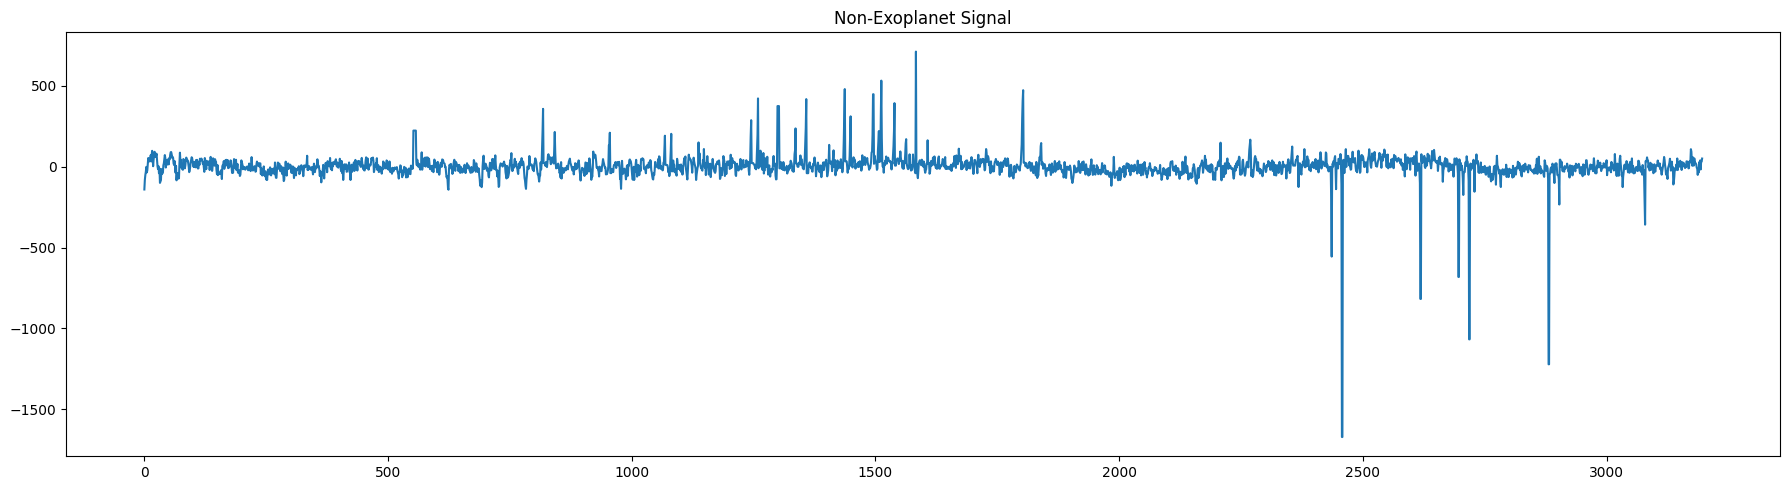

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Class Imbalance")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

planet = X_train[y_train == 1].iloc[0]
non_planet = X_train[y_train == 0].iloc[0]

plt.figure(figsize=(18, 5))
plt.plot(planet.values)
plt.title("Exoplanet Signal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5))
plt.plot(non_planet.values)
plt.title("Non-Exoplanet Signal")
plt.tight_layout()
plt.show()

# Feature Engineering Functions

In [10]:
def statistical_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = pd.DataFrame(index=df.index)

    feats["mean"] = df.mean(axis=1)
    feats["std"] = df.std(axis=1)
    feats["min"] = df.min(axis=1)
    feats["max"] = df.max(axis=1)
    feats["median"] = df.median(axis=1)
    feats["range"] = feats["max"] - feats["min"]
    feats["skew"] = df.skew(axis=1)
    feats["kurtosis"] = df.kurtosis(axis=1)
    feats["q25"] = df.quantile(0.25, axis=1)
    feats["q75"] = df.quantile(0.75, axis=1)
    feats["iqr"] = feats["q75"] - feats["q25"]

    row_mean = df.mean(axis=1)
    feats["mad"] = df.sub(row_mean, axis=0).abs().mean(axis=1)

    feats["energy"] = np.square(df).sum(axis=1)
    feats["rms"] = np.sqrt(np.square(df).mean(axis=1))

    feats["zero_crossings"] = (
        np.diff(np.sign(df.values), axis=1) != 0
    ).sum(axis=1)

    return feats


def fft_features(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for signal in df.values:
        fft_vals = np.abs(fft(signal))
        rows.append([
            fft_vals.mean(),
            fft_vals.std(),
            fft_vals.max(),
            np.argmax(fft_vals),
            np.percentile(fft_vals, 90),
            np.percentile(fft_vals, 95),
            np.percentile(fft_vals, 99)
        ])

    return pd.DataFrame(
        rows,
        columns=[
            "fft_mean",
            "fft_std",
            "fft_max",
            "fft_peak_freq",
            "fft_p90",
            "fft_p95",
            "fft_p99"
        ]
    )


def peak_features(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for signal in df.values:
        peaks, _ = find_peaks(signal)

        if len(peaks):
            peak_values = signal[peaks]
            rows.append([
                len(peaks),
                np.mean(peak_values),
                np.std(peak_values),
                np.max(peak_values),
                np.min(peak_values)
            ])
        else:
            rows.append([0, 0, 0, 0, 0])

    return pd.DataFrame(
        rows,
        columns=[
            "num_peaks",
            "peak_mean",
            "peak_std",
            "peak_max",
            "peak_min"
        ]
    )


def complexity_features(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for signal in df.values:
        diff1 = np.diff(signal)
        rows.append([
            np.mean(np.abs(diff1)),
            np.std(diff1),
            np.max(np.abs(diff1)),
            np.sum(diff1 ** 2)
        ])

    return pd.DataFrame(
        rows,
        columns=[
            "mean_abs_diff",
            "std_diff",
            "max_abs_diff",
            "diff_energy"
        ]
    )


# Feature Extraction

In [11]:
train_stat = statistical_features(X_train)
test_stat = statistical_features(X_test)

train_fft = fft_features(X_train)
test_fft = fft_features(X_test)

train_peak = peak_features(X_train)
test_peak = peak_features(X_test)

train_complex = complexity_features(X_train)
test_complex = complexity_features(X_test)

X_train_features = pd.concat(
    [train_stat, train_fft, train_peak, train_complex],
    axis=1
)

X_test_features = pd.concat(
    [test_stat, test_fft, test_peak, test_complex],
    axis=1
)

print("Feature shape:", X_train_features.shape)
display(X_train_features.head())

Feature shape: (5087, 31)


,mean,std,min,max,median,range,skew,kurtosis,q25,q75,...,fft_p99,num_peaks,peak_mean,peak_std,peak_max,peak_min,mean_abs_diff,std_diff,max_abs_diff,diff_energy
0,9.953857,160.728487,-1053.97,504.46,-0.01,1558.43,0.004394,0.410857,-103.40,118.68,...,27840.316535,818,62.983374,153.008402,504.46,-301.31,56.493889,88.684259,1346.92,2.513622e+07
1,-7.427932,60.011024,-371.27,252.64,0.01,623.91,-2.274926,10.064334,-25.18,21.43,...,15807.566539,871,16.010000,35.911952,252.64,-86.66,19.963795,38.066287,336.83,4.631140e+06
2,8.189087,281.876484,-874.95,1274.59,-0.08,2149.54,0.358711,2.205860,-129.67,158.31,...,48782.406231,816,28.364841,263.321203,1274.59,-710.09,41.484671,84.072257,860.85,2.258991e+07
3,-4.646587,103.238723,-268.41,370.29,-0.01,638.70,-0.004435,-0.027414,-78.19,69.52,...,13410.745181,891,7.964736,102.411432,370.29,-254.40,13.253667,20.971083,244.14,1.405588e+06
4,-14.240660,407.121292,-1808.76,924.32,0.02,2733.08,-0.527627,0.146406,-268.09,315.40,...,43050.905593,657,53.276225,393.660800,924.32,-1135.34,51.647137,123.702386,2160.59,4.890620e+07


# Correlation Analysis

In [12]:
corr_matrix = X_train_features.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Highly Correlated Features:", len(high_corr_features))
print(high_corr_features)

Highly Correlated Features: 13
['range', 'iqr', 'mad', 'rms', 'fft_std', 'fft_max', 'fft_p90', 'fft_p95', 'fft_p99', 'peak_std', 'peak_max', 'std_diff', 'max_abs_diff']


# Feature Selection

In [13]:
X_train_fs_df = X_train_features.drop(columns=high_corr_features)
X_test_fs_df = X_test_features.drop(columns=high_corr_features)

print("Filtered feature shape:", X_train_fs_df.shape)

Filtered feature shape: (5087, 18)


# Feature Scaling

In [14]:
scaler = RobustScaler()
X_train_fs = scaler.fit_transform(X_train_fs_df)
X_test_fs = scaler.transform(X_test_fs_df)

print(X_train_fs.shape, X_test_fs.shape)

(5087, 18) (570, 18)


# Model Evaluation Framework

In [15]:
def evaluate_model(name, y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    auc = roc_auc_score(y_true, probs)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_true, preds))
    print("ROC AUC:", auc)
    print("Confusion Matrix:\n", confusion_matrix(y_true, preds))

    return {
        "Model": name,
        "ROC_AUC": auc,
        "Accuracy": (preds == y_true).mean(),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "Threshold": threshold
    }

## Baseline Model: Logistic Regression


In [16]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=SEED
)

lr.fit(X_train_fs, y_train)
lr_probs = lr.predict_proba(X_test_fs)[:, 1]

lr_result = evaluate_model("Logistic Regression", y_test, lr_probs)


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.68      0.81       565
           1       0.03      1.00      0.05         5

    accuracy                           0.69       570
   macro avg       0.51      0.84      0.43       570
weighted avg       0.99      0.69      0.81       570

ROC AUC: 0.8945132743362831
Confusion Matrix:
 [[386 179]
 [  0   5]]


## Random Forest Classifier

In [17]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train_fs, y_train)
rf_probs = rf.predict_proba(X_test_fs)[:, 1]

rf_result = evaluate_model("Random Forest", y_test, rf_probs)


Random Forest
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       565
           1       1.00      0.40      0.57         5

    accuracy                           0.99       570
   macro avg       1.00      0.70      0.78       570
weighted avg       0.99      0.99      0.99       570

ROC AUC: 0.9948672566371681
Confusion Matrix:
 [[565   0]
 [  3   2]]


## XGBoost Classifier

In [18]:
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(X_train_fs, y_train)
xgb_probs = xgb.predict_proba(X_test_fs)[:, 1]

xgb_result = evaluate_model("XGBoost", y_test, xgb_probs)


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570

ROC AUC: 0.9755752212389379
Confusion Matrix:
 [[565   0]
 [  2   3]]


## LightGBM Classifier

In [19]:
lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(X_train_fs, y_train)
lgb_probs = lgbm.predict_proba(X_test_fs)[:, 1]

lgb_result = evaluate_model("LightGBM", y_test, lgb_probs)



LightGBM
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       565
           1       0.00      0.00      0.00         5

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       0.98      0.99      0.99       570

ROC AUC: 0.8930973451327433
Confusion Matrix:
 [[565   0]
 [  5   0]]


## CatBoost Classifier

In [20]:
cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.02,
    depth=6,
    auto_class_weights="Balanced",
    verbose=0,
    random_seed=SEED
)

cat.fit(X_train_fs, y_train)
cat_probs = cat.predict_proba(X_test_fs)[:, 1]

cat_result = evaluate_model("CatBoost", y_test, cat_probs)


CatBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570

ROC AUC: 0.9348672566371681
Confusion Matrix:
 [[565   0]
 [  2   3]]


## Ensemble Learning & Model Fusion

In [21]:
ensemble_probs = (xgb_probs + lgb_probs + cat_probs) / 3
ensemble_result = evaluate_model("Soft Voting Ensemble", y_test, ensemble_probs)

weighted_ensemble_probs = (
    0.60 * rf_probs +
    0.25 * xgb_probs +
    0.15 * cat_probs
)
weighted_ensemble_result = evaluate_model(
    "Weighted Ensemble (RF+XGB+CAT)",
    y_test,
    weighted_ensemble_probs
)

estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )),
    ("xgb", XGBClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    )),
    ("cat", CatBoostClassifier(
        iterations=1000,
        learning_rate=0.02,
        depth=6,
        auto_class_weights="Balanced",
        verbose=0,
        random_seed=SEED
    ))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=SEED),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack.fit(X_train_fs, y_train)
stack_probs = stack.predict_proba(X_test_fs)[:, 1]

stack_result = evaluate_model("Stacking Ensemble", y_test, stack_probs)



Soft Voting Ensemble
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570

ROC AUC: 0.9614159292035398
Confusion Matrix:
 [[565   0]
 [  2   3]]

Weighted Ensemble (RF+XGB+CAT)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570

ROC AUC: 0.9939823008849558
Confusion Matrix:
 [[565   0]
 [  2   3]]

Stacking Ensemble
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00 

# Model Performance Comparison

In [22]:
results = pd.DataFrame([
    lr_result,
    rf_result,
    xgb_result,
    lgb_result,
    cat_result,
    ensemble_result,
    weighted_ensemble_result,
    stack_result
])

results = results.sort_values("ROC_AUC", ascending=False)
display(results)
results.to_csv("model_results.csv", index=False)


,Model,ROC_AUC,Accuracy,Precision,Recall,F1,Threshold
1,Random Forest,0.994867,0.994737,1.000000,0.4,0.571429,0.5
6,Weighted Ensemble (RF+XGB+CAT),0.993982,0.996491,1.000000,0.6,0.750000,0.5
7,Stacking Ensemble,0.987611,0.996491,1.000000,0.6,0.750000,0.5
2,XGBoost,0.975575,0.996491,1.000000,0.6,0.750000,0.5
5,Soft Voting Ensemble,0.961416,0.996491,1.000000,0.6,0.750000,0.5
4,CatBoost,0.934867,0.996491,1.000000,0.6,0.750000,0.5
0,Logistic Regression,0.894513,0.685965,0.027174,1.0,0.052910,0.5
3,LightGBM,0.893097,0.991228,0.000000,0.0,0.000000,0.5


# Cross-Validation Analysis

In [23]:
rf_cv = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

scores = cross_val_score(
    rf_cv,
    X_train_fs,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("CV scores:", scores)
print("Mean ROC AUC:", scores.mean())
print("Std:", scores.std())

ci_low = max(0, scores.mean() - 1.96*scores.std())
ci_high = min(1, scores.mean() + 1.96*scores.std())
print("95% CI:", ci_low, ci_high)

CV scores: [0.81998762 0.96027228 0.99717115 1.         1.        ]
Mean ROC AUC: 0.9554862093352192
Std: 0.06940225093666195
95% CI: 0.8194577974993618 1


# Decision Threshold Optimization

In [24]:
oof_rf_probs = cross_val_predict(
    rf_cv,
    X_train_fs,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.01, 1.00, 0.01):
    preds = (oof_rf_probs >= threshold).astype(int)
    score = f1_score(y_train, preds)
    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best OOF Threshold:", best_threshold)
print("Best OOF F1:", best_f1)

Best OOF Threshold: 0.16
Best OOF F1: 0.8823529411764706


# Final Model Evaluation

In [25]:
rf_final_preds = (rf_probs >= best_threshold).astype(int)

print(classification_report(y_test, rf_final_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_final_preds))
print("ROC AUC:", roc_auc_score(y_test, rf_probs))
print("Accuracy:", (rf_final_preds == y_test).mean())

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570

Confusion Matrix:
 [[565   0]
 [  2   3]]
ROC AUC: 0.9948672566371681
Accuracy: 0.9964912280701754


# Confusion Matrix Analysis

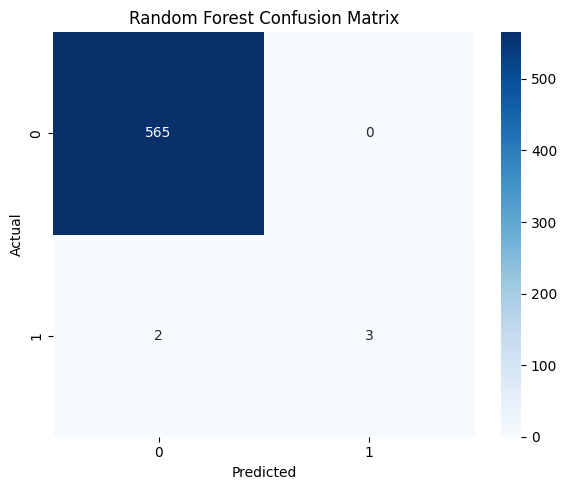

In [26]:
cm = confusion_matrix(y_test, rf_final_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve Analysis

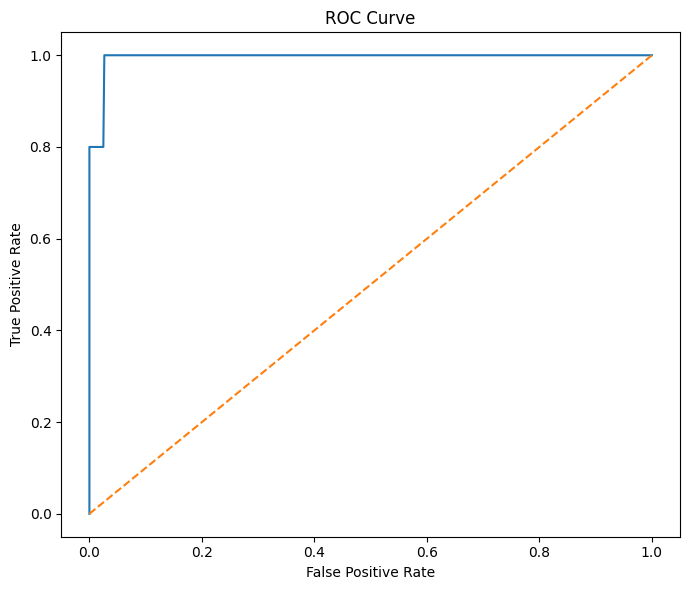

In [27]:
fpr, tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

## Model Explainability & Feature Importance

,Feature,Importance
4,median,0.251027
13,num_peaks,0.144278
15,peak_min,0.073148
5,skew,0.069861
2,min,0.045533
1,std,0.043082
0,mean,0.037648
9,energy,0.036156
6,kurtosis,0.034689
10,zero_crossings,0.034633


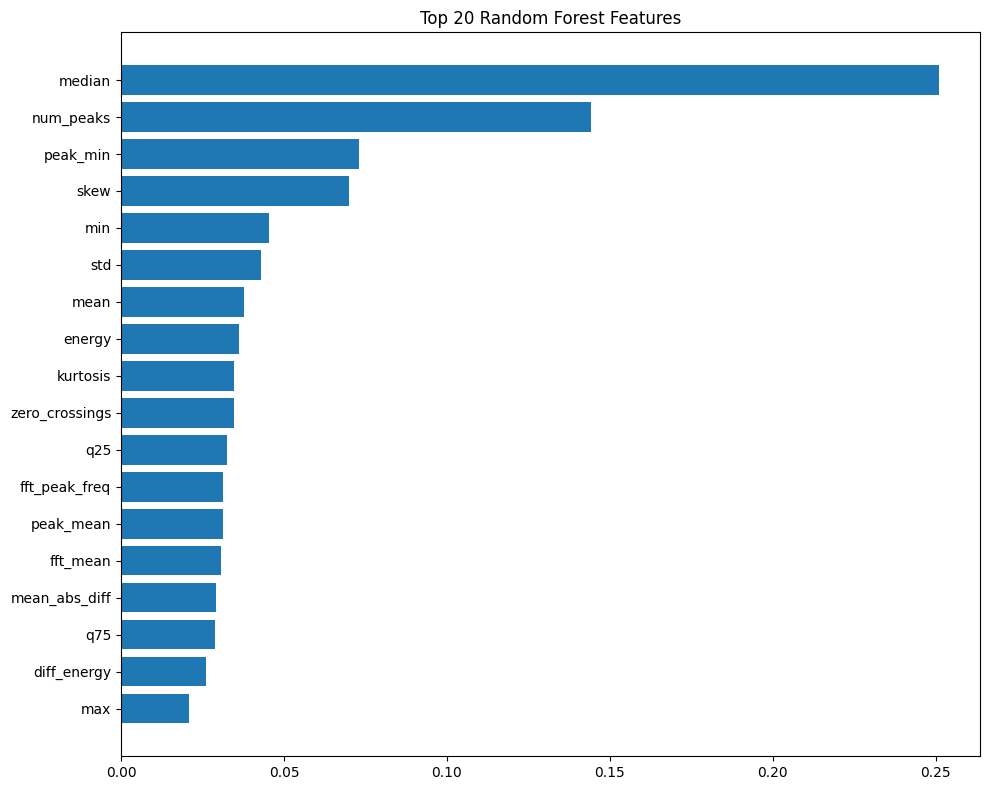

,Feature,Importance
4,median,0.005000
13,num_peaks,0.001404
15,peak_min,0.000789
0,mean,0.000000
1,std,0.000000
2,min,0.000000
6,kurtosis,0.000000
7,q25,0.000000
3,max,0.000000
5,skew,0.000000


In [28]:
feature_names = X_train_fs_df.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 8))
top = importance_df.head(20)
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Random Forest Features")
plt.tight_layout()
plt.show()

perm_importance = permutation_importance(
    rf,
    X_test_fs,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_train_fs_df.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

display(perm_df.head(20))

# Ablation Study

In [29]:
def evaluate_rf_on_feature_set(train_feat_df, test_feat_df, y_train, y_test, name):
    drop_cols = [c for c in high_corr_features if c in train_feat_df.columns]

    train_use = train_feat_df.drop(columns=drop_cols, errors="ignore")
    test_use = test_feat_df.drop(columns=drop_cols, errors="ignore")

    local_scaler = RobustScaler()
    Xtr = local_scaler.fit_transform(train_use)
    Xte = local_scaler.transform(test_use)

    model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(Xtr, y_train)

    probs = model.predict_proba(Xte)[:, 1]
    preds = (probs >= 0.5).astype(int)

    return {
        "Feature_Set": name,
        "ROC_AUC": roc_auc_score(y_test, probs),
        "Accuracy": (preds == y_test).mean(),
        "F1": f1_score(y_test, preds)
    }


ablation_results = []

ablation_results.append(
    evaluate_rf_on_feature_set(
        train_stat, test_stat, y_train, y_test, "Statistical only"
    )
)

ablation_results.append(
    evaluate_rf_on_feature_set(
        pd.concat([train_stat, train_fft], axis=1),
        pd.concat([test_stat, test_fft], axis=1),
        y_train, y_test,
        "Stat + FFT"
    )
)

ablation_results.append(
    evaluate_rf_on_feature_set(
        pd.concat([train_stat, train_fft, train_peak], axis=1),
        pd.concat([test_stat, test_fft, test_peak], axis=1),
        y_train, y_test,
        "Stat + FFT + Peak"
    )
)

ablation_results.append(
    evaluate_rf_on_feature_set(
        pd.concat([train_stat, train_fft, train_peak, train_complex], axis=1),
        pd.concat([test_stat, test_fft, test_peak, test_complex], axis=1),
        y_train, y_test,
        "Stat + FFT + Peak + Complexity"
    )
)

ablation_results.append(
    evaluate_rf_on_feature_set(
        X_train_features,
        X_test_features,
        y_train, y_test,
        "All features"
    )
)

ablation_df = pd.DataFrame(ablation_results).sort_values("ROC_AUC", ascending=False)
display(ablation_df)
ablation_df.to_csv("ablation_results.csv", index=False)

,Feature_Set,ROC_AUC,Accuracy,F1
4,All features,0.994867,0.994737,0.571429
3,Stat + FFT + Peak + Complexity,0.994867,0.994737,0.571429
0,Statistical only,0.991150,0.994737,0.571429
2,Stat + FFT + Peak,0.988496,0.994737,0.571429
1,Stat + FFT,0.982124,0.994737,0.571429


# Precision-Recall Analysis

Average Precision Score: 0.8500000000000001


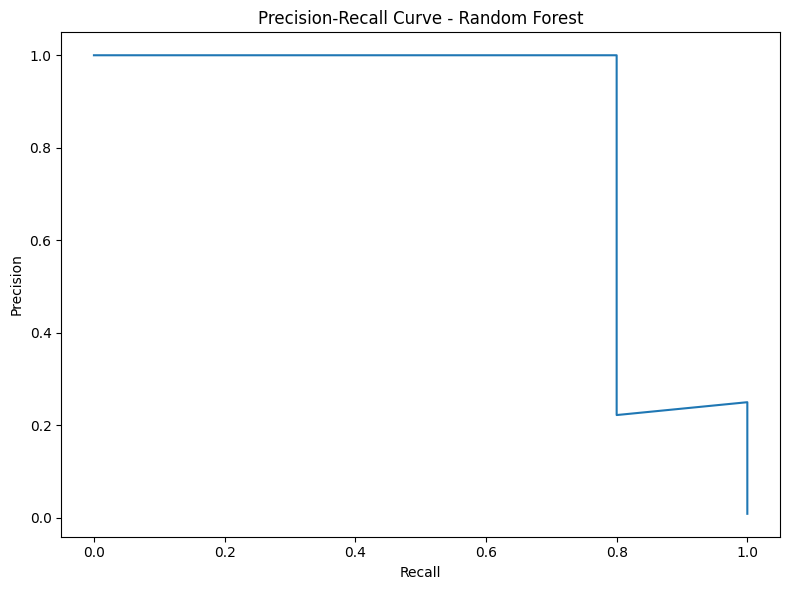

In [30]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)
ap_score = average_precision_score(y_test, rf_probs)

print("Average Precision Score:", ap_score)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.tight_layout()
plt.show()

# Probability Calibration Analysis

Brier Score: 0.004447171929824561


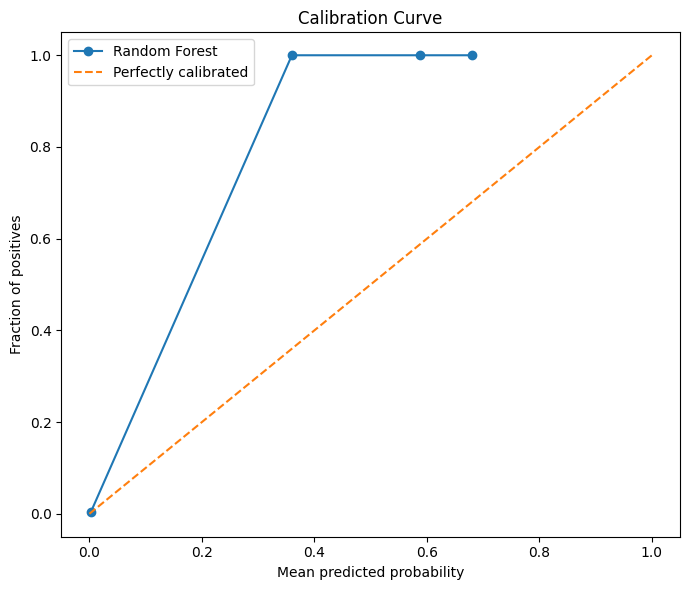

In [31]:
brier = brier_score_loss(y_test, rf_probs)
prob_true, prob_pred = calibration_curve(y_test, rf_probs, n_bins=10, strategy="uniform")

print("Brier Score:", brier)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Error Analysis

False Negatives: 2
False Positives: 0


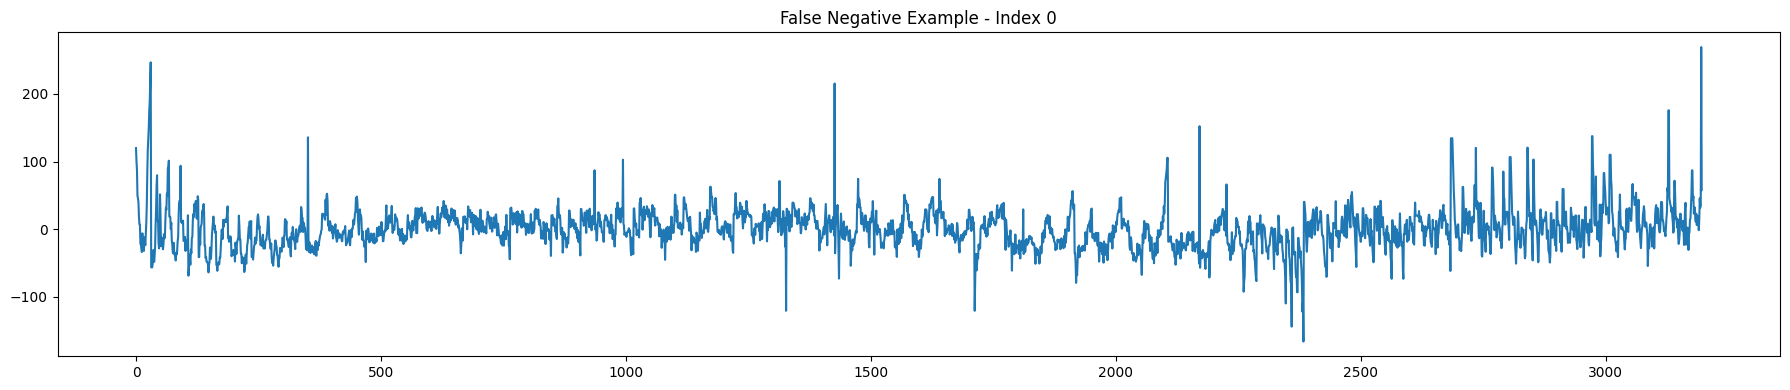

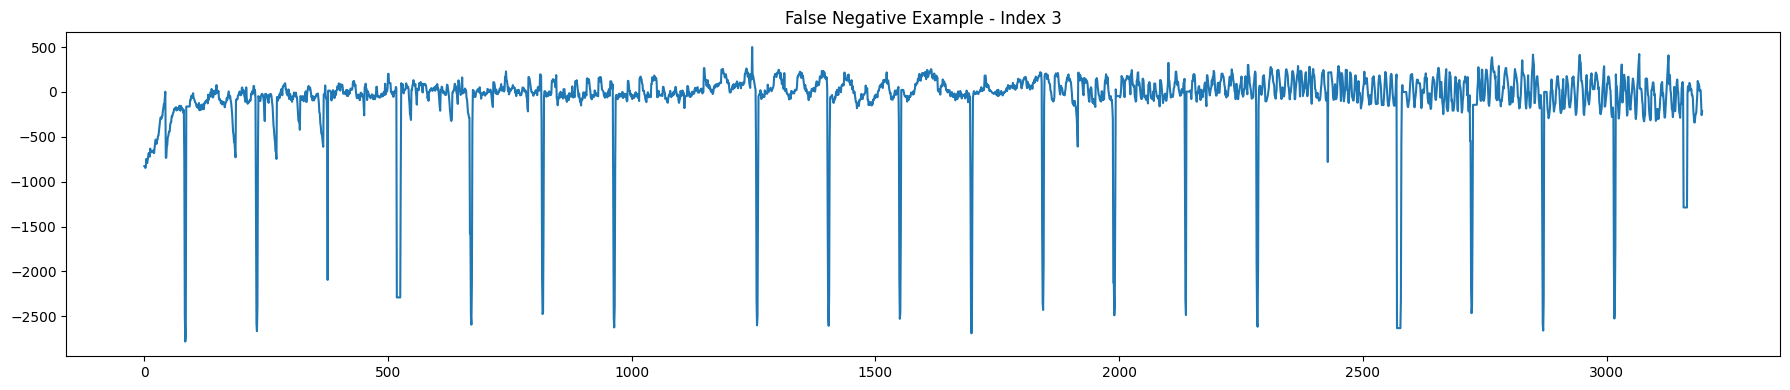

In [32]:
false_neg_idx = np.where((y_test.values == 1) & (rf_final_preds == 0))[0]
false_pos_idx = np.where((y_test.values == 0) & (rf_final_preds == 1))[0]

print("False Negatives:", len(false_neg_idx))
print("False Positives:", len(false_pos_idx))

for idx in false_neg_idx[:3]:
    plt.figure(figsize=(18, 4))
    plt.plot(X_test.iloc[idx].values)
    plt.title(f"False Negative Example - Index {idx}")
    plt.tight_layout()
    plt.show()

for idx in false_pos_idx[:3]:
    plt.figure(figsize=(18, 4))
    plt.plot(X_test.iloc[idx].values)
    plt.title(f"False Positive Example - Index {idx}")
    plt.tight_layout()
    plt.show()

# Robustness Analysis

In [33]:
noise_levels = [0.01, 0.05, 0.10, 0.20]
noise_results = []

for noise in noise_levels:
    X_noisy = pd.DataFrame(
        X_test.values + np.random.normal(0, noise, X_test.shape),
        columns=X_test.columns,
        index=X_test.index
    )

    noisy_stat = statistical_features(X_noisy)
    noisy_fft = fft_features(X_noisy)
    noisy_peak = peak_features(X_noisy)
    noisy_complex = complexity_features(X_noisy)

    noisy_features = pd.concat(
        [
            noisy_stat,
            noisy_fft,
            noisy_peak,
            noisy_complex
        ],
        axis=1
    )

    noisy_features = noisy_features.drop(columns=high_corr_features, errors="ignore")
    noisy_features = noisy_features[X_train_fs_df.columns]

    noisy_scaled = scaler.transform(noisy_features)
    noisy_probs = rf.predict_proba(noisy_scaled)[:, 1]
    noisy_auc = roc_auc_score(y_test, noisy_probs)

    noise_results.append([noise, noisy_auc])

noise_df = pd.DataFrame(noise_results, columns=["Noise_Level", "ROC_AUC"])
display(noise_df)
noise_df.to_csv("noise_results.csv", index=False)

,Noise_Level,ROC_AUC
0,0.01,0.931327
1,0.05,0.949912
2,0.10,0.941062
3,0.20,0.717168


# Model Persistence & Artifact Export

In [34]:
raw_feature_columns = X_train.columns.tolist()
selected_feature_columns = X_train_fs_df.columns.tolist()

joblib.dump(rf, "rf_exoplanet_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(raw_feature_columns, "raw_feature_columns.pkl")
joblib.dump(selected_feature_columns, "selected_feature_columns.pkl")
joblib.dump(high_corr_features, "dropped_correlated_features.pkl")

pipeline_info = {
    "best_model": "Random Forest",
    "roc_auc": float(roc_auc_score(y_test, rf_probs)),
    "threshold": float(best_threshold),
    "selected_feature_columns": selected_feature_columns,
    "dropped_correlated_features": high_corr_features,
    "train_shape": list(X_train.shape),
    "test_shape": list(X_test.shape)
}

with open("pipeline_info.json", "w") as f:
    json.dump(pipeline_info, f, indent=2)

with open("best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print("Saved model and pipeline artifacts.")

Saved model and pipeline artifacts.


# Inference Pipeline

In [35]:
def predict_exoplanet(raw_signal_df: pd.DataFrame):
    stat = statistical_features(raw_signal_df)
    fftf = fft_features(raw_signal_df)
    peakf = peak_features(raw_signal_df)
    compf = complexity_features(raw_signal_df)

    feat_df = pd.concat([stat, fftf, peakf, compf], axis=1)
    feat_df = feat_df.drop(columns=high_corr_features, errors="ignore")
    feat_df = feat_df[selected_feature_columns]

    scaled = scaler.transform(feat_df)
    probs = rf.predict_proba(scaled)[:, 1]
    preds = (probs >= best_threshold).astype(int)

    return pd.DataFrame({
        "probability": probs,
        "prediction": preds
    })


# Optional demo prediction on first 5 test rows
demo_predictions = predict_exoplanet(X_test.iloc[:5].copy())
display(demo_predictions)

,probability,prediction
0,0.066,0
1,0.588,1
2,0.680,1
3,0.020,0
4,0.360,1


## Final Performance Comparison

In [36]:
final_summary = pd.DataFrame([
    lr_result,
    rf_result,
    xgb_result,
    lgb_result,
    cat_result,
    ensemble_result,
    weighted_ensemble_result,
    stack_result
]).sort_values("ROC_AUC", ascending=False)

display(final_summary)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1,Threshold
1,Random Forest,0.994867,0.994737,1.000000,0.4,0.571429,0.5
6,Weighted Ensemble (RF+XGB+CAT),0.993982,0.996491,1.000000,0.6,0.750000,0.5
7,Stacking Ensemble,0.987611,0.996491,1.000000,0.6,0.750000,0.5
2,XGBoost,0.975575,0.996491,1.000000,0.6,0.750000,0.5
5,Soft Voting Ensemble,0.961416,0.996491,1.000000,0.6,0.750000,0.5
4,CatBoost,0.934867,0.996491,1.000000,0.6,0.750000,0.5
0,Logistic Regression,0.894513,0.685965,0.027174,1.0,0.052910,0.5
3,LightGBM,0.893097,0.991228,0.000000,0.0,0.000000,0.5


# FEATURE IMPORTANCE PLOT

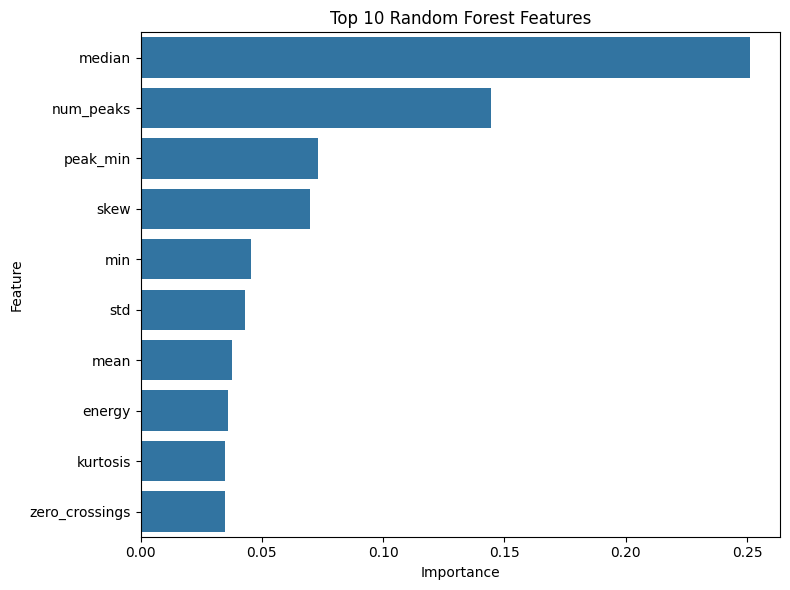

BEST MODEL
Random Forest
ROC AUC : 0.9948672566371681
Threshold: 0.16


In [37]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Random Forest Features")
plt.tight_layout()
plt.show()


print("=" * 60)
print("BEST MODEL")
print("=" * 60)
print("Random Forest")
print("ROC AUC :", roc_auc_score(y_test, rf_probs))
print("Threshold:", best_threshold)